Note book 内容提要：
    1. 欧式期权定价公式和隐含波动率求解
    2. SVI 隐含波动率参数化
    3. 使用有限差分方法计算 Dupire 局部波动率的数值方法
    4. 傅里叶变换方法求解 BCC 随机波动率加跳模型

一、 欧式期权定价通常会采用两个方程：

    (1) 以现货资产为标的物的BSM方程，这类期权称为“现货期权”；
    (2) 以期货合约做为标的物的Black方程，这类期权称为“期货期权”。
    
两者其实没有实质差别，但是在计算中会体现出差异。
目前郑商所、大商所的期权都是以期货合约为标的物的期货合约，沪深两所的300ETF和50ETF期权则是以现货资产作为标的物的期权。比较有意思的的是中金所IO，中金所IO的标的是沪深300指数现货，但是IO的交割日期与IF的交割日期一致，所以IO也可以看作是以相同到期月期货合约为标的的期货期权。

期权定价的解析公式是通过求解BSM方程或Black方程获得到的显式解，所以只有边界条件清晰的期权才能获得明确的解析公式（这里不解释什么叫“边界条件”），简言之就是简单的期权可以通过直接求解方程的，所谓简单的期权主要包括欧式期权和美式看涨期权。在风险中性的测度下，不提前行权是美式看涨期权多头的最优策略，所以在定价时可以将美式看涨期权当作欧式看涨期权进行处理，但是美式看跌期权则不能通过简单的解析公式获得期权的价格，而是需要和复杂的奇异期权一样采用数值方法求解。

二、 常用的数值方法可以概括为四类：

    (1) 有限差分法；
    (2) 树形方法；
    (3) 傅里叶变换；
    (4) 蒙特卡洛模拟。

这四种数值方法涵盖了几乎所有期权定价问题中会涉及到的数值方法，四种方法各有优势，在进行隐含波动率建模时应当根据建模的方法来选择数值方法。
本篇采用的建模方法是基于概率密度的建模方法，数值方法主要是有限差分和隐含树形两种。本篇中主要会用到的方法是有限差分法，主要就是为了偷个懒，很早以前我就写过了一版有限差分的代码，这次直接搬到帖子里就行。选择差分方法的另外一个原因是差分方法可以适用于几乎所有模型，只要对Black-Scholes方程或Black方程进行离散化，根据期权的特性给出对应的边界条件即可。
在利用随机波动率、跳跃扩散、CEV等建模方法时，通常可以采用傅里叶变换的方法来快速得到期权价格，尽管有限差分法可能会更精确，但是傅里叶变换在求解的速度上优势更明显。
蒙特卡洛模拟则可以更直观地获得期权定价，但是代价就是计算成本会比较高，毕竟需要重复数十万次的计算，但是在交易频率相对较低的场景下这中计算成本也不是不可容忍，甚至是可以忽略的。

In [1]:
import datetime
import jqdata as jq
import numpy as np
import pandas as pd
from scipy.stats import norm
from scipy.optimize import root
from scipy.optimize import minimize

def get_option_ticks(option_list,minute,frequency = '1m'):
    # 每1分钟为一个最小的单元，查看期权的tick数据，简单化处理，考虑在买一和卖一之间
    fields = ['time','current','position','volume',
              'a1_p','b1_p','a1_v','b1_v']
    
    t = int(frequency[:-1])
    opt_ticks = []
    for opt in option_list:
        # 行权价有时候会因为标的价格波动而调整造成同一到期日下有两组行权价相同的认购认沽，
        # 这种情况下我仍然把这两个认购期权看作是同一个期权，两个认沽同理。
        ticks = pd.DataFrame(get_ticks(opt,
                             start_dt = minute - datetime.timedelta(seconds = int(60 * t)),
                             end_dt = minute, fields = fields), columns = fields)
        if len(ticks) > 0:
            ticks.loc[:,'code'] = opt
            opt_ticks.append(ticks)
    if len(opt_ticks) > 0:
        opt_ticks = pd.concat(opt_ticks,
                               axis = 0).reset_index(drop = True
                                                    ).sort_values('time',
                                                                  ascending = True)#.to_dict()
    else:
        opt_ticks = pd.DataFrame()
    return opt_ticks

underlying_code = '000300.XSHG'
date = '2021-10-18'
date_zero = datetime.date(2021,10,18)
minute = datetime.datetime(2021,10,18,14,30,0)

contract = jq.opt.run_query(query(jq.opt.OPT_CONTRACT_INFO
                                      ).filter(jq.opt.OPT_CONTRACT_INFO.underlying_symbol == underlying_code
                                              ).filter(jq.opt.OPT_CONTRACT_INFO.list_date <= date
                                                      ).filter(jq.opt.OPT_CONTRACT_INFO.last_trade_date >= date)
                                   ).set_index('code')

contract = contract[contract.contract_type == 'CO']
option_list = contract.index.tolist()
ticks = get_option_ticks(option_list,minute).sort_values('time')
ticks = ticks.groupby('code').tail(1).set_index('code')

underlying = {'future_code':{},'future_price':{},'spot_price':{}}
for i in option_list:
    underlying['future_code'][i] = 'IF' + i[2:6] + '.CCFX'
    underlying['spot_price'][i] = get_price(underlying_code, 
                                       start_date = minute, end_date = minute, 
                                       frequency = '30m', fields = 'close').iloc[0,0]

    try:
        underlying['future_price'][i] = get_price(underlying['future_code'][i], 
                                           start_date = minute, end_date = minute, 
                                           frequency = '30m', fields = 'close').iloc[0,0]
    except:
        pass
    
risk_free = 0.0232 # 查了当天深交所91天国债逆回购的收盘利率
q = 0 # 假设红绿率为0
common = list(set(ticks.index) & set(contract.index))
maturity_days = (contract.loc[common,'expire_date'] - date_zero)
maturity = maturity_days / datetime.timedelta(days = 365)
maturity_days = maturity * 365

maturity_days.name = 'maturity_days'
maturity.name = 'maturity'

underlying = pd.DataFrame(underlying).loc[common,:]

moneyness = np.log(underlying.future_price.fillna(underlying.spot_price) / contract.exercise_price).loc[common]
moneyness_spot = np.log(underlying.spot_price / contract.exercise_price).loc[common]

moneyness.name = 'moneyness'
moneyness_spot.name = 'moneyness_spot'

contract_ticks = pd.concat([underlying,
                            contract.loc[common,['exercise_price','expire_date']],
                            maturity_days, maturity,moneyness,moneyness_spot,
                            ticks.loc[common,:]], axis = 1).sort_values('maturity', axis = 0)
contract_ticks

ERROR:root:retry_bcolz_open failed, p=/opt/data/jq/bundle/futures1m/01/IF2201.CCFX, mode=r, carray=False
Traceback (most recent call last):
  File "/opt/conda/lib/python3.6/site-packages/jqdata/stores/bcolz_utils.py", line 26, in retry_bcolz_open
    return jqbcolz.ctable(rootdir=p, mode='r', mmap=True)
  File "/opt/conda/lib/python3.6/site-packages/jqbcolz/ctable.py", line 272, in __init__
    self._open_ctable()
  File "/opt/conda/lib/python3.6/site-packages/jqbcolz/ctable.py", line 370, in _open_ctable
    self.cols.read_meta_and_open()
  File "/opt/conda/lib/python3.6/site-packages/jqbcolz/ctable.py", line 65, in read_meta_and_open
    with open(rootsfile, 'rb') as rfile:
FileNotFoundError: [Errno 2] No such file or directory: '/opt/data/jq/bundle/futures1m/01/IF2201.CCFX/__rootdirs__'
ERROR:root:retry_bcolz_open failed, p=/opt/data/jq/bundle/futures1m/01/IF2201.CCFX, mode=r, carray=False
Traceback (most recent call last):
  File "/opt/conda/lib/python3.6/site-packages/jqdata/store

ERROR:root:retry_bcolz_open failed, p=/opt/data/jq/bundle/futures1m/01/IF2201.CCFX, mode=r, carray=False
Traceback (most recent call last):
  File "/opt/conda/lib/python3.6/site-packages/jqdata/stores/bcolz_utils.py", line 26, in retry_bcolz_open
    return jqbcolz.ctable(rootdir=p, mode='r', mmap=True)
  File "/opt/conda/lib/python3.6/site-packages/jqbcolz/ctable.py", line 272, in __init__
    self._open_ctable()
  File "/opt/conda/lib/python3.6/site-packages/jqbcolz/ctable.py", line 370, in _open_ctable
    self.cols.read_meta_and_open()
  File "/opt/conda/lib/python3.6/site-packages/jqbcolz/ctable.py", line 65, in read_meta_and_open
    with open(rootsfile, 'rb') as rfile:
FileNotFoundError: [Errno 2] No such file or directory: '/opt/data/jq/bundle/futures1m/01/IF2201.CCFX/__rootdirs__'
ERROR:root:retry_bcolz_open failed, p=/opt/data/jq/bundle/futures1m/01/IF2201.CCFX, mode=r, carray=False
Traceback (most recent call last):
  File "/opt/conda/lib/python3.6/site-packages/jqdata/store

,future_code,future_price,spot_price,exercise_price,expire_date,maturity_days,maturity,moneyness,moneyness_spot,time,current,position,volume,a1_p,b1_p,a1_v,b1_v
code,,,,,,,,,,,,,,,,,
IO2111-C-5000.CCFX,IF2111.CCFX,4845.8,4863.04,5000.0,2021-11-19,32.0,0.087671,-0.031326,-0.027774,2.021102e+13,43.8,5738.0,5639.0,44.0,43.6,18.0,12.0
IO2111-C-5300.CCFX,IF2111.CCFX,4845.8,4863.04,5300.0,2021-11-19,32.0,0.087671,-0.089594,-0.086043,2.021102e+13,6.2,3935.0,1743.0,6.4,6.0,25.0,26.0
IO2111-C-5600.CCFX,IF2111.CCFX,4845.8,4863.04,5600.0,2021-11-19,32.0,0.087671,-0.144654,-0.141103,2.021102e+13,2.0,1448.0,228.0,2.2,2.0,39.0,9.0
IO2111-C-4650.CCFX,IF2111.CCFX,4845.8,4863.04,4650.0,2021-11-19,32.0,0.087671,0.041245,0.044797,2.021102e+13,232.0,171.0,157.0,233.0,230.8,7.0,8.0
IO2111-C-4750.CCFX,IF2111.CCFX,4845.8,4863.04,4750.0,2021-11-19,32.0,0.087671,0.019968,0.023519,2.021102e+13,158.6,1582.0,1184.0,158.8,157.6,6.0,2.0
IO2111-C-4700.CCFX,IF2111.CCFX,4845.8,4863.04,4700.0,2021-11-19,32.0,0.087671,0.030550,0.034101,2.021102e+13,194.6,554.0,645.0,194.2,193.0,9.0,1.0
IO2111-C-5400.CCFX,IF2111.CCFX,4845.8,4863.04,5400.0,2021-11-19,32.0,0.087671,-0.108287,-0.104735,2.021102e+13,3.4,1804.0,840.0,3.6,3.2,60.0,32.0
IO2111-C-4500.CCFX,IF2111.CCFX,4845.8,4863.04,4500.0,2021-11-19,32.0,0.087671,0.074035,0.077586,2.021102e+13,352.0,126.0,49.0,363.6,360.4,6.0,9.0
IO2111-C-4900.CCFX,IF2111.CCFX,4845.8,4863.04,4900.0,2021-11-19,32.0,0.087671,-0.011123,-0.007571,2.021102e+13,77.4,4495.0,8705.0,77.8,77.2,20.0,6.0


In [2]:
# 这一节是基础的欧式期权定价公式
# 整理一下，只分bsm和black两个函数
def bsm(s0,sigma,t,r,q,strike,model = 'black', out_put = 'greeks'):
    discount = np.exp(-r * t)
    if model == 'black':
        d1 = (np.log(s0 / strike) + (0.5 * sigma**2) * t) / (sigma * np.sqrt(t))
    
    elif model == 'bsm':
        d1 = (np.log(s0 / strike) + (r - q + 0.5 * sigma**2) * t) / (sigma * np.sqrt(t))
        
    d2 = d1 - sigma * np.sqrt(t)
    p = norm.cdf(d2)
    
    if out_put == 'greeks':
        call = {}
        call['delta'] = norm.cdf(d1)
        call['gamma'] = norm.pdf(d1) / (s0 * sigma * np.sqrt(t))
        call['vega'] = s0 * np.sqrt(t) * norm.pdf(d1)
        call['rho'] = strike * t * discount * p
        call['theta'] = - (s0 * norm.pdf(d1) * sigma 
                           /
                           (2 * np.sqrt(t))
                           ) - r * strike * discount * p
        call['dcdk'] = discount * p

        put = {}
        put['delta'] = call['delta'] - 1
        put['gamma'] = call['gamma']
        put['vega'] = call['vega']
        put['rho'] = strike * t * discount * (1 - p)
        put['theta'] = - (s0 * norm.pdf(d1) * sigma 
                          /
                          (2 * np.sqrt(t))
                           ) + r * strike * discount * (1 - p)
        put['dcdk'] = discount * (1 - p)

        if model == 'bsm':
            call['value'] = s0 * call['delta'] - strike * discount * p
            put['value'] = strike * discount * (1 - p) + s0 * put['delta']

        elif model == 'black':
            call['value'] = discount * (s0 * call['delta'] - strike * p)
            put['value'] = discount * (strike * (1 - p) + s0 * put['delta'])
        
        return [call,put]

    elif out_put == 'call':
        if model == 'bsm':
            call = s0 * norm.cdf(d1) - strike * discount * p

        elif model == 'black':
            call = discount * (s0 * norm.cdf(d1) - strike * p)
        
        return call
    
    elif out_put == 'put':
        if model == 'bsm':
            put = strike * discount * (1 - p) + s0 * (norm.cdf(d1) - 1)

        elif model == 'black':
            put = discount * (strike * (1 - p) + s0 * (norm.cdf(d1) - 1))

        return put


In [8]:
# 用真实数据求解隐含波动率
# 取收盘前最后一个tick的买卖报价作为建模的对象
# 期权价格计算隐含波动率
def implied_vol_call(s0,k,T,r,q,market_price,contract_type,model = 'black'):
    if contract_type == 'CO':
        iv = root(lambda iv : (bsm(s0,iv,T,r,q,k,model,out_put = 'call') / market_price - 1)
                  ,x0 = 1, tol = 1e-3)
        
    elif contract_type == 'PO':
        iv = root(lambda iv : (bsm(s0,iv,T,r,q,k,model,out_put = 'put') / market_price - 1)
                  ,x0 = 1, tol = 1e-3)

    return iv

contract_ticks = contract_ticks.to_dict()
contract_ticks['a1_iv'] = {}
contract_ticks['b1_iv'] = {}

contract_type = 'CO'
for i in contract_ticks['a1_p']:
    if str(contract_ticks['future_price'][i]) == 'nan':
        solve_a = implied_vol_call(contract_ticks['spot_price'][i],
                                   contract_ticks['exercise_price'][i],
                                   contract_ticks['maturity'][i],
                                   risk_free, q,
                                   contract_ticks['a1_p'][i],
                                   contract_type,
                                   model = 'bsm')
        solve_b = implied_vol_call(contract_ticks['spot_price'][i],
                                   contract_ticks['exercise_price'][i],
                                   contract_ticks['maturity'][i],
                                   risk_free, q,
                                   contract_ticks['b1_p'][i],
                                   contract_type,
                                   model = 'bsm')

    else:
        solve_a = implied_vol_call(contract_ticks['future_price'][i],
                                   contract_ticks['exercise_price'][i],
                                   contract_ticks['maturity'][i],
                                   risk_free, q,
                                   contract_ticks['a1_p'][i],
                                   contract_type)
        solve_b = implied_vol_call(contract_ticks['future_price'][i],
                                   contract_ticks['exercise_price'][i],
                                   contract_ticks['maturity'][i],
                                   risk_free, q,
                                   contract_ticks['b1_p'][i],
                                   contract_type)

    contract_ticks['a1_iv'][i] = solve_a.x[0]
    contract_ticks['b1_iv'][i] = solve_b.x[0]

contract_ticks = pd.DataFrame(contract_ticks)
initial_iv = {}
for g in contract_ticks.groupby('expire_date'):
    initial_iv[g[0]] = g[1].set_index('exercise_price').loc[:,['a1_iv','b1_iv']].mean(axis = 1).sort_index()
pd.DataFrame(initial_iv).T

exercise_price,4200.0,4250.0,4300.0,4350.0,4400.0,4450.0,4500.0,4550.0,4600.0,4650.0,4700.0,4750.0,4800.0,4850.0,4900.0,4950.0,5000.0,5100.0,5200.0,5300.0,5400.0,5500.0,5600.0,5800.0,6000.0,6200.0,6400.0
2021-11-19,NaN,0.269647,0.257269,0.243392,0.229793,0.220244,0.211127,0.203903,0.196234,0.191205,0.187067,0.182922,0.180538,0.179345,0.178070,0.177574,0.177459,0.177041,0.181393,0.186780,0.194280,0.210458,0.229334,NaN,NaN,NaN,NaN
2021-12-17,0.253981,NaN,0.238289,0.229808,0.224911,0.217880,0.214356,0.209835,0.203494,0.200675,0.197675,0.195221,0.192162,0.191070,0.190455,0.188933,0.189154,0.188003,0.189948,0.189944,0.195635,0.200794,0.209035,0.226348,0.250748,0.276028,0.307134
2022-01-21,NaN,NaN,NaN,NaN,0.019282,NaN,0.115156,0.127405,0.137248,0.143912,0.148891,0.152587,0.155847,0.158520,0.160770,0.162846,0.164487,0.167814,0.170882,0.174150,0.177199,0.179057,NaN,NaN,NaN,NaN,NaN
2022-03-18,0.218954,NaN,NaN,NaN,0.205046,NaN,0.201120,NaN,0.197777,NaN,0.193792,NaN,0.192438,NaN,0.191672,NaN,0.192504,NaN,0.192255,NaN,0.192538,NaN,0.198079,0.202980,0.210250,NaN,NaN
2022-06-17,NaN,NaN,0.210255,NaN,0.207652,NaN,0.202771,NaN,0.199758,NaN,0.197203,NaN,0.195233,NaN,0.193937,NaN,0.193127,NaN,0.192065,NaN,0.193603,NaN,0.194951,0.199473,NaN,NaN,NaN
2022-09-16,NaN,NaN,0.013661,NaN,0.038207,NaN,0.103132,NaN,0.117846,NaN,0.126797,NaN,0.133312,NaN,0.138332,NaN,0.142433,NaN,0.149220,NaN,0.154875,NaN,0.160718,NaN,NaN,NaN,NaN


上面的内容搞定了两件事情：
    1. 完成了期权定价的解析公式和希腊字母；
    2. 展示了隐含波动率的计算方法。
从上面一行的输出当中可以看到，1月和9月到期的期权隐含波动率和其他四个到期月的期权隐含波动率有十分明显的差异，这个差异主要是由于前期处理时我将有IF到期的月份的IO当做了期货期权，二正好1月和9月还没有IF上市，这两个到期月的期权隐含波动率则是依据沪深300现货价格和交易所国债逆回购计算出来的。在后续的处理中我将只针对有IF的月份进行处理。

接下来就到了对波动率微笑进行建模的环节。我将采用的方法包括四个步骤：
    1. 调整期权报价数据，排除报价数据中的无套利机会；
    2. 对无套利的报价数据进行插值得到期权价格函数（将期权价格看作是关于敲定价和到期日）；
    3. 根据期权波动率函数的表达式，对期权价格函数求偏导数得到局部波动率网格；
    4. 利用局部波动率网格求解期权定价方程的数值解。

第一步工作是对期权价格数据进行无套利的处理，要让一组期权价格数据中不存在蝶式套利和日历套利机会。蝶式套利曾在期权策略（上篇）中提到，本篇的主要目标是建模，依照蝶式组合总价格大于0的基本原则我们可以将存在套利机会的期权价格直接改成无套利机会的价格。进行这种调整时应保持平值附近的期权价格不变（尤其是成交量或持仓量最大的一张期权），若存在套利机会则将其他的期权价格调整为无套利边界内的价格；其次，在进行调整时，应尽可能在买卖挂单的价格范围内进行调整。

In [9]:
'''
无套利化处理的第一步是排除基础性的定价失误
期权首先满足凸性，它的价格至少大于当下期货价格与行权价之差，若期货价格低于行权价则期权价值至少大于0
这种套利机会通常只会发生在深度实值的时候
'''
def exclude_basic_arbitrage(contract_ticks):
    contract_ticks.loc[:,'lower_boundary'] = (contract_ticks.loc[:,'future_price'].fillna(
                                                contract_ticks.loc[:,'spot_price'] * 
                                                np.exp(- risk_free *contract_ticks.loc[:,'maturity']))
                                             ) - contract_ticks.loc[:,'exercise_price']
    contract_ticks.loc[:,'lower_boundary'] = contract_ticks.loc[:,'lower_boundary'].where(contract_ticks.loc[:,'lower_boundary'] > 0, 0)
    '''
    在我选取的时间点上，IO2111-C-4250.CCFX 的价格就低于套利边界，市场上卖价为604.2个指数点，而套利边界是610点
    当市场上有此等好事的时候应该坚决买进3张期权，做空1手IF2111.CCFX，
    如此交易将会获得大约 5*300 = 1500人民币的无风险套利收益
    '''
    return contract_ticks.sort_values('maturity')

contract_ticks = exclude_basic_arbitrage(contract_ticks)
contract_ticks

,future_code,future_price,spot_price,exercise_price,expire_date,maturity_days,maturity,moneyness,moneyness_spot,time,current,position,volume,a1_p,b1_p,a1_v,b1_v,a1_iv,b1_iv,lower_boundary
IO2111-C-4250.CCFX,IF2111.CCFX,4845.8,4863.04,4250.0,2021-11-19,32.0,0.087671,0.131193,0.134745,2.021102e+13,590.0,33.0,19.0,604.2,600.4,9.0,6.0,0.283363,0.255931,595.80000
IO2111-C-5600.CCFX,IF2111.CCFX,4845.8,4863.04,5600.0,2021-11-19,32.0,0.087671,-0.144654,-0.141103,2.021102e+13,2.0,1448.0,228.0,2.2,2.0,39.0,9.0,0.230910,0.227757,0.00000
IO2111-C-5500.CCFX,IF2111.CCFX,4845.8,4863.04,5500.0,2021-11-19,32.0,0.087671,-0.126636,-0.123084,2.021102e+13,2.6,1681.0,425.0,2.6,2.4,22.0,9.0,0.211754,0.209162,0.00000
IO2111-C-5400.CCFX,IF2111.CCFX,4845.8,4863.04,5400.0,2021-11-19,32.0,0.087671,-0.108287,-0.104735,2.021102e+13,3.4,1804.0,840.0,3.6,3.2,60.0,32.0,0.196232,0.192329,0.00000
IO2111-C-5300.CCFX,IF2111.CCFX,4845.8,4863.04,5300.0,2021-11-19,32.0,0.087671,-0.089594,-0.086043,2.021102e+13,6.2,3935.0,1743.0,6.4,6.0,25.0,26.0,0.188024,0.185536,0.00000
IO2111-C-5100.CCFX,IF2111.CCFX,4845.8,4863.04,5100.0,2021-11-19,32.0,0.087671,-0.051128,-0.047577,2.021102e+13,22.8,6301.0,4680.0,23.0,22.4,17.0,9.0,0.177865,0.176217,0.00000
IO2111-C-5000.CCFX,IF2111.CCFX,4845.8,4863.04,5000.0,2021-11-19,32.0,0.087671,-0.031326,-0.027774,2.021102e+13,43.8,5738.0,5639.0,44.0,43.6,18.0,12.0,0.177870,0.177047,0.00000
IO2111-C-4950.CCFX,IF2111.CCFX,4845.8,4863.04,4950.0,2021-11-19,32.0,0.087671,-0.021275,-0.017724,2.021102e+13,58.6,3053.0,3361.0,59.0,58.6,2.0,19.0,0.177950,0.177197,0.00000
IO2111-C-4900.CCFX,IF2111.CCFX,4845.8,4863.04,4900.0,2021-11-19,32.0,0.087671,-0.011123,-0.007571,2.021102e+13,77.4,4495.0,8705.0,77.8,77.2,20.0,6.0,0.178604,0.177535,0.00000
IO2111-C-4850.CCFX,IF2111.CCFX,4845.8,4863.04,4850.0,2021-11-19,32.0,0.087671,-0.000866,0.002685,2.021102e+13,100.4,3307.0,5390.0,100.8,100.0,28.0,7.0,0.180046,0.178645,0.00000


In [10]:
# 再排除蝶式套利机会
def exclude_arbitrage(contract_ticks,contract_type = 'CO', iv_boundary = 0.1, adj = 0.4):
    maturity_set = contract_ticks.expire_date.drop_duplicates().sort_values().tolist()
    spot = contract_ticks.spot_price.iloc[0]
    ask = {}
    bid = {}
    for h in contract_ticks.groupby('expire_date'):
        # 只取 买一价对应的隐含波动率大于隐含波动边界的期权进行处理
        ask[h[0]] = h[1][h[1].b1_iv > iv_boundary].set_index('exercise_price').a1_p
        bid[h[0]] = h[1][h[1].b1_iv > iv_boundary].set_index('exercise_price').loc[:,['lower_boundary','b1_p']].max(axis = 1)
    
    bid = pd.DataFrame(bid).sort_index().T.sort_index().T
    sample = pd.Series(bid.loc[:,maturity_set].count(axis = 1).index).sort_values()
    left = sample[sample <= spot].tolist()
    right = sample[sample >= spot].tolist()
    atmr = min(right)
    atml = max(left)
    left = left + [atmr]
    right = [atml] + right
    sample_t = bid.columns.tolist()
    ask = pd.DataFrame(ask).loc[sample,sample_t]
    bid = bid.loc[sample,:]
    mid = ((bid + ask) / 2).to_dict()
    for t in mid:
        ind_t = sample_t.index(t)
        scale_left = pd.Series(bid[t]).loc[left].dropna().index.tolist()
        if len(scale_left) >= 3:
            for k3 in scale_left[::-1]:
                ind = scale_left.index(k3)
                k2 = scale_left[ind - 1]
                k1 = scale_left[ind - 2]
                mid[t][k1] = max(mid[t][k1], adj + 2 * mid[t][k2] - mid[t][k3])

                if scale_left.index(k1) == 0:
                    break
                    
        scale_right = pd.Series(bid[t]).loc[right].dropna().index.tolist()
        if len(scale_right) >= 3:
            for k3 in scale_right:
                ind = scale_right.index(k3)
                k2 = scale_right[ind + 1]
                k1 = scale_right[ind + 2]
                mid[t][k1] = max(min(mid[t][k1], mid[t][k2]), adj + 2 * mid[t][k2] - mid[t][k3])

                if scale_right.index(k1) == len(scale_right) - 1:
                    break
    
    # -----------------------------------------------------------
    return pd.DataFrame(mid)

mid = exclude_arbitrage(contract_ticks)

至此，我们可以用排除套利后的 ask 和 bid 计算新的隐含波动率，再通过插值获得其他敲定价下的波动率来进行定价和对冲。
但是在若我们需要对BSM模型进行补充（让波动率不再是一个常数），则我们还需要考虑对波动率曲面进行建模。
本文将采取Jim Gatheral 提出的SVI的参数化方法拟合各个期限的波动率微笑的表达式，然后再依据波动率微笑曲线的表达式进行插值来获得市场上任意敲定价、任意期限的欧式期权价格，最终利用这个欧式期权价格的网格来得出局部波动率网格。

得到无套利的期权价格以后我们马上可以进行的一步工作就是重新计算隐含波动率，获得新的隐含波动率微笑的形态，再依据新的波动率微笑计算每个期权的希腊值。
另一方面，那么获得无套利曲面之后我们还可以为波动率曲面建模，根据波动率曲面再重新计算期权的希腊值。
在本文中我选择用一种比较简单直接的建模方式就是 Bruno Dupire 的局部波动率模型。
这个模型是一个非参数模型，它的优点是只要能够获得一组场内欧式期权的价格我们就能通过插值来获得整个局部波动率曲面，然后可以依据这个局部波动率曲面来计算对冲比率、进行奇异期权定价等工作。

In [11]:
# 无套利的调整会改变期权的价格，所以重新计算一版隐含波动率
def svi_iv(mid,contract_ticks,risk_free, q = 0,contract_type = 'CO'):
    iv = {}
    solve = {}
    success = {}
    columns = mid.columns.tolist()
    
    spot = contract_ticks.spot_price.iloc[0]

    for t in mid.columns:
        future = contract_ticks.future_price[contract_ticks.expire_date == t].iloc[0]
        maturity = contract_ticks.maturity[contract_ticks.expire_date == t].iloc[0]
        if columns.index(t) > 0:
            sub_mid = mid.loc[:,t][mid.loc[:,t].fillna(0) > mid.iloc[:,columns.index(t) - 1]]
        else:
            sub_mid = mid.loc[:,t].dropna()
        iv[t] = {}
        solve[t] = {}
        success[t] = {}

        for k in sub_mid.index:
            if str(future) == 'nan':
                solve[t][k] = implied_vol_call(spot, k, maturity, risk_free, q, sub_mid.loc[k],
                                               contract_type, model = 'bsm')

            else:
                solve[t][k] = implied_vol_call(future, k, maturity, risk_free, q, sub_mid.loc[k],
                                               contract_type)

            success[t][k] = solve[t][k].success
            if solve[t][k].success == True:
                iv[t][k] = solve[t][k].x[0]
    return [pd.DataFrame(iv),pd.DataFrame(success),solve]

iv_matrix, success, solve = svi_iv(mid,contract_ticks,risk_free)
iv_matrix.T

,4250.0,4300.0,4350.0,4400.0,4450.0,4500.0,4550.0,4600.0,4650.0,4700.0,4750.0,4800.0,4850.0,4900.0,4950.0,5000.0,5100.0,5200.0,5300.0,5400.0,5500.0,5600.0,5800.0
2021-11-19,0.275469,0.258748,0.243871,0.230152,0.220427,0.211241,0.203947,0.196249,0.191214,0.187068,0.182923,0.180538,0.179345,0.178070,0.177574,0.177459,0.194158,0.193170,0.186791,0.194315,0.210475,0.229357,NaN
2021-12-17,NaN,0.238577,0.231013,0.224989,0.217944,0.214391,0.209863,0.203502,0.200677,0.197675,0.195221,0.192162,0.191070,0.190455,0.188933,0.189155,0.205997,0.215302,0.216497,0.206326,0.200795,0.209068,NaN
2022-01-21,NaN,NaN,NaN,NaN,NaN,0.116113,0.127472,0.137267,0.143922,0.148894,0.152588,0.155847,0.158520,0.160770,0.162846,0.164487,0.181619,0.193168,0.199615,0.200664,0.194876,NaN,NaN
2022-03-18,NaN,NaN,NaN,NaN,NaN,0.201132,NaN,0.197779,NaN,0.193792,NaN,0.192438,NaN,0.191672,NaN,0.192504,NaN,0.213413,NaN,0.221318,NaN,NaN,NaN
2022-06-17,NaN,NaN,NaN,0.207657,NaN,0.202772,NaN,0.199758,NaN,0.197203,NaN,0.195233,NaN,0.193937,NaN,0.193127,NaN,0.209725,NaN,0.217899,NaN,0.217726,0.207015
2022-09-16,NaN,NaN,NaN,NaN,NaN,0.103163,NaN,0.117852,NaN,0.126798,NaN,0.133312,NaN,0.138332,NaN,0.142433,NaN,0.163746,NaN,0.176789,NaN,0.183049,NaN


In [12]:
# 进行 SVI 参数化
def svi(moneyness,param):
    a,b,rho,m,sig = param
    return a + b * (rho * (moneyness - m) + np.sqrt((moneyness - m) ** 2 + sig ** 2))

def loss_svi(iv,moneyness,param):
    '''
    最小二乘法进行参数优化
    限制条件: 
        1. b >= 0;
        2. abs(rho) < 1
    '''
    a,b,rho,m,sig = param
    svi_para = svi(moneyness,param)

    if b < 0 or abs(rho) >= 1 or svi_para.min() < 0 or sig < 0:
        # 限制方法也很简单，直接让损失函数返回一个很大的值就行
        return 10000
    else:
        return (iv ** 2 - svi_para).pow(2).mean()
    
def calibrate_svi(contract_ticks,iv_matrix,para0 = [0,0.5,0,0,0.05]):
    svi_calibrated = {}
    moneyness = {}
    atm = {}
    spot = contract_ticks.spot_price.iloc[0]

    for t in iv_matrix.columns:
        future = contract_ticks.future_price[contract_ticks.expire_date == t].iloc[0]
        iv = iv_matrix.loc[:,t].dropna()
        if str(future) == 'nan':
            moneyness[t] = np.log(pd.Series(iv_matrix.index, index = iv_matrix.index) / spot)
            atm[t] = spot

        else:
            moneyness[t] = np.log(pd.Series(iv_matrix.index, index = iv_matrix.index) / future)
            atm[t] = future

        svi_calibrated[t] = minimize(lambda param : loss_svi(iv_matrix.loc[:,t].dropna(),
                                                                moneyness[t].loc[iv.index], param), para0)
    return [svi_calibrated,pd.DataFrame(moneyness),atm]

svi_calibrated,moneyness,atm = calibrate_svi(contract_ticks,iv_matrix)

# 看一下参数化的结果
para = {}
for i in svi_calibrated:
    para[i] = pd.Series(svi_calibrated[i].x, index = ['a','b','rho','m','sig'])
    print(i, '优化结果:', svi_calibrated[i].fun, '| 迭代成功：',svi_calibrated[i].success)
para = pd.DataFrame(para)
print('下面是SVI的参数')
para

2021-11-19 优化结果: 3.010460794885744e-06 | 迭代成功： True
2021-12-17 优化结果: 8.945300086810605e-06 | 迭代成功： True
2022-01-21 优化结果: 3.2917032991712044e-06 | 迭代成功： True
2022-03-18 优化结果: 1.2301465462326602e-06 | 迭代成功： True
2022-06-17 优化结果: 7.0103926039614715e-06 | 迭代成功： True
2022-09-16 优化结果: 7.655113048000586e-07 | 迭代成功： True
下面是SVI的参数


,2021-11-19,2021-12-17,2022-01-21,2022-03-18,2022-06-17,2022-09-16
a,-0.094178,-0.072803,-0.355275,-0.064961,-0.147698,-0.262170
b,1.096146,0.420488,0.262662,0.446553,0.278794,0.262597
rho,-0.680822,-0.003115,0.006016,-0.003772,-0.012601,0.011884
m,-0.135269,0.031985,-0.713510,-0.003578,-0.008130,-0.389170
sig,0.156939,0.262474,1.256586,0.228113,0.672511,0.991137


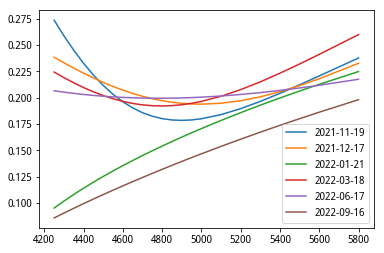

In [13]:
# 参数化后的隐含波动率微笑
iv_svi = {}
for i in svi_calibrated:
    iv_svi[i] = pd.Series(svi(moneyness.loc[:,i], svi_calibrated[i].x) ** 0.5,
                          index = moneyness.index)
iv_svi = pd.DataFrame(iv_svi)
iv_svi.plot()

看到上面这个图的时候我惊呼：哇塞！有交易机会，11月、12月、3月、6月的波动率微笑曲线有相交的点，过两天写个回测试试。

上图中一个显著的问题是1月到期的期权和9月到期的期权波动率实在是太特立独行了，别人都是曲线，而这两位接近于直线，1月那位甚至是凹函数，我之前也尝试过用沪深300现货指数作为标的去计算隐含波动率，最终出现了六条直线（这里有个捂脸表情🤦‍♂️🤦‍♀️），所以后续无决定暂时放弃1月和9月两个到期月，只对有期货的四个期限进行建模。


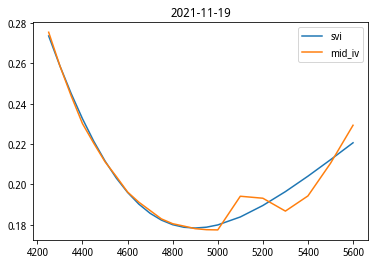

In [14]:
# 这里输入期限序号看每个期限上隐含波动率的拟合效果
t = 0
pd.DataFrame({'svi':iv_svi.iloc[:,t],'mid_iv':iv_matrix.iloc[:,t]}
            ).dropna().plot(title = str(iv_matrix.iloc[:,0].name))

上述的方法基本上已经可以得到隐含波动率在四个关键期限上的参数化表达式，借用这个四个参数化表达式我们可以推导出任意执行价格的期权价值，若只是需要利用参数化表达式计算四个期限上的场内的Black （或BSM）隐含波动率和希腊字母则可以简单地将期权的在值程度（moneyness）作为输入参数即可得出Black隐含波动率，再将这个隐含波动率代入BSM的公式中就可以求出期权的价值和希腊值。

我采用SVI更重要的一个目是通过参数化来解决局部波动率建模过程中涉及到的插值问题，通过SVI的参数化表达式可以得到四个关键期限上任意一个执行价格对应的Black 隐含波动率，那么我们只需要在时间维度上进行插值就可以得到计算局部波动率所需要的”所有“期权价值。

In [10]:
from scipy.interpolate import make_interp_spline
def get_local_vol(underlying, days, min_qoute, r, q = 0, model = 'black'):
    dt = t / min(100,days) # 对于剩余长度大于100个自然日的期权则取100个区间，除此之外，以1天为离散化的最小单位
    ds = (underlying - min_qoute) / 1000
    t_grid, s_grid = np.meshgrid(dt * np.arange(min(100,days) + 1), ds * np.arange(2001))
    s_grid += min_qoute
    t_grid[:,0] += t_grid[:,1] / 100
    
    iv_svi = {}
    iv_svi_up = {}
    iv_svi_down = {}
    for i in svi_calibrated:
        iv_svi[i] = pd.Series(svi(np.log(s_grid[:,0] / underlying),
                                  svi_calibrated[i].x), s_grid[:,0])
        iv_svi_up[i] = pd.Series(svi(np.log((s_grid[:,0] + dt) / underlying),
                                     svi_calibrated[i].x), index = s_grid[:,0])
        iv_svi_down[i] = pd.Series(svi(np.log((s_grid[:,0] - dt) / underlying),
                                       svi_calibrated[i].x), index = s_grid[:,0])
    iv_svi = pd.DataFrame(iv_svi)
    iv_svi_up = pd.DataFrame(iv_svi_up)
    iv_svi_down = pd.DataFrame(iv_svi_down)

    maturities = contract_ticks.dropna().set_index('expire_date').maturity.drop_duplicates()

    interp = make_interp_spline(maturities, iv_svi.loc[:,maturities.index].T)
    interp_longer = interp(t_grid[0,:] + dt).T
    interp = interp(t_grid[0,:]).T
    interp_up = make_interp_spline(maturities, iv_svi_up.loc[:,maturities.index].T)(t_grid[0,:]).T
    interp_down = make_interp_spline(maturities, iv_svi_down.loc[:,maturities.index].T)(t_grid[0,:]).T
    # 然后是隐含波动率对执行价和剩余期限的倒数
    div2_dk2 = (interp_up - 2 * interp + interp_down) / (ds ** 2)
    div_dt = (interp_longer - interp) / dt
    div_dk = 0.5 * ((interp_up - interp) + (interp - interp_down)) / (ds)

    if model == 'black':
        d1 = (np.log(underlying / s_grid) + (0.5 * interp**2) * t_grid) / (interp * np.sqrt(t_grid))
        lv = (div_dt + (interp / t_grid)
             ) / (s_grid ** 2 * (div2_dk2 - d1 * np.sqrt(t_grid) * div_dk**2 + 
                                ((1 / (s_grid * np.sqrt(t_grid))) + d1 * div_dk) ** 2 / interp))

    elif model == 'bsm':
        d1 = (np.log(underlying / s_grid) + (r - q + 0.5 * interp**2) * t_grid) / (interp * np.sqrt(t_grid))
        lv = (div_dt + (interp / t_grid) + (2 * s_grid * (r - q) * div_dk)
             ) / (s_grid ** 2 * (div2_dk2 - d1 * np.sqrt(t_grid) * div_dk**2 + 
                                ((1 / (s_grid * np.sqrt(t_grid))) + d1 * div_dk) ** 2 / interp))
    return [s_grid,t_grid,lv * 2,ds,dt,interp]



In [11]:
# 有限差分法进行期权定价
# 在场内交易的场景中，定价的环节最重要的意义是计算对冲比率、支持风险管理
from scipy import linalg

def ifd_bs_call(strike,s_grid,ds,t,dt,sigma,r,q = 0, model = 'black'):
    call = np.zeros_like(s_grid)
    call[:,len(call.T) - 1] = s_grid[:,len(call.T) - 1] - strike
    call[:,len(call.T) - 1][call[:,len(call.T) - 1] < 0] = 0
    call[-1,:] = s_grid[-1,len(call.T) - 1] - strike
    call[0,:] = 0

    vet = (s_grid[:,0] - min_qoute) / ds + 1
    for i in range(len(s_grid.T)-1,0,-1):
        if type(sigma) == float:
            sig = 0
        else:
            sig = sigma[:,i]
        if model == 'black':
            a = - 0.5 * ((sig * vet)**2) * dt# lower
            b = 1 + (r + (sig * vet)**2) * dt# middle
            c = - 0.5 * ((sig * vet)**2) * dt# upper
        elif model == 'bsm':
            a = 0.5 * ((r - q) * vet - (sig * vet)**2) * dt# lower
            b = 1 + (r + (sig * vet)**2) * dt# middle
            c = - 0.5 * ((r - q) * vet + (sig * vet)**2) * dt# upper

        mat = (np.diag(b) + 
               np.column_stack((np.row_stack((np.zeros(len(a[1:])),
                                              np.diag(a[1:]))),
                                np.zeros(len(a)))) + 
                np.column_stack((np.zeros(len(c)),
                                 np.row_stack((np.diag(c[:-1]),
                                               np.zeros(len(c[:-1])))))))[1:-1,1:-1]
        plus = np.zeros_like(call[1:-1,i])
        plus[0] = a[1] * call[0,i]
        plus[-1] = c[-2] * call[-1,i]
        call[1:-1,i-1] = linalg.solve(mat,call[1:-1,i] - plus)
        
    return call

In [12]:
# 触发有限差分，这一步初始化差分网格，
# 这里只取
spot = contract_ticks.spot_price.iloc[0]
min_qoute = 0.2
strike = 4850

model = 'black'
for g in contract_ticks.dropna().groupby('expire_date'):# dropna去掉没有期货的两个期限
    underlying = g[1].future_price.iloc[0]
    t = g[1].maturity.iloc[0]
    days = int(round(365 * t))
    s_grid,t_grid,lv,ds,dt,interp = get_local_vol(underlying, days, min_qoute, risk_free)
    r = risk_free
    
    # sigma 是通过SVI 参数化之后再插值的到的局部波动率曲面
    # sigma1 是BSM隐含波动率
    sigma = np.sqrt(np.where(lv > 0, lv, lv[lv > 0].min()))
    sigma1 = 0.168 + np.zeros_like(s_grid)
    call = ifd_bs_call(strike, s_grid, ds, t, dt, sigma, risk_free)
    call1 = ifd_bs_call(strike, s_grid, ds, t, dt, sigma1, risk_free)

    print('SVI 插值局部波动率: ',call[1000,0])
    print('BSM 隐含波动率: ' ,call1[1000,0])
    print('买一卖一中间价: ' ,mid.loc[strike,g[0]])
    # 其中一个期权进行定价, 看看定价效果，所以到这里我们现break
    break


SVI 插值局部波动率:  25.064413137185323
BSM 隐含波动率:  100.92430119323721
买一卖一中间价:  100.4


从上面的定价效果可以看出来直接用SVI拟合场内期权波动率再在时间维度上进行插值并不能获得一个理想的定价效果，但是这种想法对于Bruno Duire 公式的应用却并不是错误的，定价失误的原因主要来自于插值过程中引入的误差。
我在插值的环节使用的是B样条插值，如果使用其他插值方法的话就会得到完全不一样的局部波动率曲面，那么就会得到一个完全不一样的定价效果，但是更换插值方法也并不是一个有效的解决方案，因为计算局部波动率的方法需要对隐含波动率取二阶导数（差分形式），这种计算方法本身就对于数值及其敏感，输入数据的微小变化就会导致结果千差万别，这也是局部波动率在实际使用的环节中最大的问题。
第二个我认为存在的问题是上面的方法其实并没有进行任何的优化，也就是说我们的局部波动率曲面并不是完全符合市场的。

解决局部波动率模型存在的问题大概有两种不同的思路，一种是引入Arrow-Debreu证券作为工具来计算局部波动率，这种思路下有两种方法，一种是Derman和Kani（1997）提出的隐含树形方法，另外一种则是Andersen等（1997）提出的有限差分方法，这两种方法中后者的方法和我上面的执行流程基本一致，但是在进行计算差分网格中的线性方程组的时候（ifd_bs_call中变量名为 mat）会采用Arrow-Debreu证券来调整由插值的到的局部波动率曲面，当然，这个过程中涉及到优化。好吧，上面说了那么多我还是承认我对局部波动率的校对有点烂尾了，局部波动率是一个关于标的价格和到期日的二元函数，无论Andersen等（1997）的论文里说得再细致我总之还没有理解到其中精髓，因为我们此时需要优化的是一个不知道表达式的函数，那么这里面涉及到一些泛函分析的的内容，作为非数学专业的我还是补补课再拿出来秀吧（最近就在补课，学好了就来更新帖子）。

当然了，我们还可以干脆放弃局部波动率模型，直接采用随机波动率模型或者混合概率密度的模型。在随机波动率模型中我比较喜欢Heston随机波动率加跳扩散的模型，这个模型包含了Heston（1993）的随机波动率模型和Merton（1976）的跳扩散模型，喜欢它的原因是在两位作者的原文中就给出了随机波动率和跳扩散两个随机过程的特征函数，那么我们只需要计算特征函数再通过傅里叶变换就能快速地校对模型参数，得到模型参数之后就可以计算出场内期权的希腊值，另外在对于奇异期权定价时也可以通过蒙特卡洛模拟给出定价和希腊值。

但是，我还是会需要一个能够补足Black-Scholes中对于波动率假设的不足的一个工具，所以接下来我将祭出Heston（1993）随机波动率加Merton（1976）跳扩散的模型作为本篇的收尾。这个模型由Bakshi等（1997）的文章中被提出，在Gatheral的波动率建模讲义《波动率曲面》（电子工业出版社，2017年）有非常详细的讲解和说明，这本书也是我的第一本期权建模的学习资料。

说到这里不禁感叹，这篇帖子最初是我用来学习Dupire局部波动率的一个练习，当然学习的结果是理解了这个模型，但是在实现的角度我还是回到了几年前就学会的模型上了，希望我能尽快学懂局部波动率的优化方法吧，我觉得我并不用把泛函分析学到数学专业本科的水平应该就能理解了吧。

In [80]:
# 这一部分给出heston93模型和merton76模型的特征函数以及定价代码
# 不像上面的代码还稍有些乱，这些接下来这些代码算是我这几年压箱底的老东西了，这次拿出来秀一秀
from scipy.integrate import quad

# -----------------------------------------------------------
def heston93_char_func(u,T,r,q,kappa_v,theta_v,sigma_v,rho,v0):
    # characteristic function

    c1 = kappa_v * theta_v
    c2 = - np.sqrt((rho * sigma_v * u * 1j - kappa_v) ** 2 - (-u * 1j - u**2) * sigma_v**2)
    c3 = (kappa_v - rho * sigma_v * u * 1j + c2) / (kappa_v - rho * sigma_v * u * 1j - c2)
    
    h1 = ((r - q) * u * 1j * T + (c1 / sigma_v**2) * 
          ((kappa_v - rho * sigma_v * u * 1j + c2) * T - 
           2 * np.log((1 - c3 * np.exp(c2 * T)) / (1 - c3))))
    
    h2 = ((kappa_v - rho * sigma_v * u * 1j + c2) / sigma_v**2) * \
          ((1 - np.exp(c2 * T)) / (1 - c3 * np.exp(c2 * T)))
    print(c1,c2,c3,h1,h2)
    return np.exp(h1 + h2 * v0)

def heston93_int_func(u,s0,k,T,r,q,kappa_v,theta_v,sigma_v,rho,v0):
    # function being integreted
    char_value = heston93_char_func(u - 1j * 0.5,T,r,q,kappa_v,theta_v,sigma_v,rho,v0)
    int_value = (np.exp(1j * u * np.log(s0 / k)) * char_value).real / (u**2 + 0.25)
    print(int_value)
    return int_value
    
def heston93_vanilla_call(s0, k, T, r, q, kappa_v, theta_v, sigma_v, rho, v0):
    '''
    
    Parameters
    ----------
    s0 : TYPE
        Initial stock price
    k : TYPE
        Strike of option
    T : TYPE
        Time to maturity
    r : TYPE
        Risk free interest rate
    kappa_v : TYPE
        Mean-reversion factor
    theta_v : TYPE
        Long-run mean of variance
    sigma_v : TYPE
        Volatility of variance
    rho : TYPE
        Correlation between variance and stock/index level
    v0 : TYPE
        Initial level of variance

    Returns
    -------
        value of vanilla call option

    '''
    int_value = quad(lambda u : heston93_int_func(u,s0,k,T,r,q,kappa_v,theta_v,sigma_v,rho,v0),
                                          0, np.inf, limit = 250)[0]
    call_value = max(0, s0 * np.exp(-q * T) - np.exp(- (r + q) * T / 2) * np.sqrt(s0 * k) * int_value / np.pi)
    return call_value

# -----------------------------------------------------------
def merton76_char_func(u, T, r, sigma, lamb, mu, delta):
    omega = (r - q) - 0.5 * sigma**2 - lamb * (np.exp(mu + 0.5 * delta ** 2) - 1)
    char_value = np.exp((1j * u * omega - 0.5 * (u * sigma)**2  + 
                         lamb * (np.exp(1j * u * mu - u**2 * delta**2 * 0.5) - 1)) * T)
    return char_value

def merton76_int_func(u,s0,k,T,r, q, sigma, lamb, mu, delta):
    # function being integreted
    char_value = merton76_char_func(u - 1j * 0.5, T, r, sigma, lamb, mu, delta)
    int_value = (np.exp(1j * u * (np.log(s0 / k) + (r - q) * T)) * char_value).real / (u**2 + 0.25)
    return int_value

def merton76_vanilla_call(s0, k, T, r, q, sigma, lamb, mu, delta):
    '''    

    Parameters
    ----------
    s0 : float
        Initial stock price
    k : float
        Strike of option
    T : flaot
        Time to maturity
    r : float
        Risk free interest rate
    lamb : float
        jump intensity
    mu : float
        expected jump size
    delta : float
        standard deviation of jump

    Returns
    -------
    call_value : float
        the price of vanilla call option.

    '''

    int_value = quad(lambda u : merton76_int_func(u, s0, k, T, r, q, sigma,
                                                   lamb, mu, delta),
                     0, np.inf,
                     limit = 250)[0]
    call_value = max(0, s0 * np.exp(-q * T) - np.exp(-(r + q) * T / 2) * np.sqrt(s0 * k) * int_value / np.pi)
    return call_value

# -----------------------------------------------------------
def merton76_bcc_char_func(u, T, lamb, mu, delta):
    omega = - lamb * (np.exp(mu + 0.5 * delta ** 2) - 1)
    char_value = np.exp((1j * u * omega + 
                         lamb * (np.exp(1j * u * mu - u**2 * delta**2 * 0.5) - 1)) * T)
    return char_value

def bcc97_char_func(u, T, r, q,
                    kappa_v, theta_v, sigma_v, rho, v0,
                    lamb, mu, delta):
    bcc1 = heston93_char_func(u, T, r,kappa_v, theta_v, sigma_v, rho, v0)
    bcc2 = merton76_bcc_char_func(u, T,lamb, mu, delta)
    return bcc1 * bcc2

def bcc97_int_func(u, s0, k, T, r, q,
                 kappa_v, theta_v, sigma_v, rho, v0,
                 lamb, mu, delta):
    char_value = bcc97_char_func(u - 1j * 0.5, T, r, q, kappa_v, theta_v, sigma_v, rho, v0,
                                 lamb, mu, delta)
    int_value = (np.exp(1j * u * (np.log(s0 / k) + (r - q) * T)) * char_value).real / (u**2 + 0.25)
    return int_value

def bcc97_vanilla_call(s0, k, T, r, q,
                       kappa_v, theta_v, sigma_v, rho, v0,
                       lamb, mu, delta):
    '''    

    Parameters
    ----------
    s0 : float
        Initial stock price
    k : float
        Strike of option
    T : flaot
        Time to maturity
    r : float
        Risk free interest rate
    kappa_v : float
        Mean-reversion factor
    theta_v : float
        Long-run mean of variance
    sigma_v : float
        Volatility of variance
    rho : float
        Correlation between variance and stock/index level
    v0 : float
        Initial level of variance
    lamb : float
        jump intensity
    mu : float
        expected jump size
    delta : float
        standard deviation of jump

    Returns
    -------
    call_value : float
        the price of vanilla call option.

    '''
    int_value = quad(lambda u : bcc97_int_func(u, s0, k, T, r, q,
                                               kappa_v, theta_v, sigma_v, rho, v0,
                                               lamb, mu, delta),
                     0, np.inf, limit = 250)[0]
    call_value = max(0, s0 * np.exp(-q * T) - np.exp(-(r+q) * T / 2) * np.sqrt(s0 * k) * int_value / np.pi)
    return call_value


In [82]:
heston93_char_func(1,underlying.iloc[0],# maturity.iloc[0], underlying.iloc[0],
                      risk_free, 0, 0.54,0.04,1,-0.7,0.4)

0.0216 (-1.1687408786377842-0.7512358094493498j) (-0.2285590400010436+0.1641309442992391j) (-65.80058058421534+107.05400732710281j) (-0.6287408786377842-0.0512358094493498j)


(2.0110063571781264e-29+4.483547390866387e-30j)

上面的内容包括Heston93、Merton76、BCC97三个模型的特征函数、定价函数、参数优化函数，接下来是使用上述方法的思路。

    1.参数估计的总体思路
        我将会分别对Heston93和Merton76两个模型进行参数估计，然后再将两个模型的参数作为BCC97的初值再进行优化。
        
    2.对Heston93和Merton76模型进行参数估计时如何选择初值
        选择初值是个很复杂的问题，接下来将会选择在比较大颗粒度的空间里进行穷举搜索，然后用穷举结果中的最优值作为进一步优化的初值。
      
    3.正则化
        在分别估计了Heston93和Merton76两个模型的参数之后我们相当于得到了一组“不差”的BCC97参数，所以在将这组参数作为BCC97的初值时就将采取L2正则化的方法避免由于8个参数堆叠带来的过拟合。


In [81]:
# 这一部分根据上面的代码进行参数估计,先定义损失函数
def heston93_error(underlying,market_price,maturity,param,r,q = 0):
    kappa_v,theta_v,sigma_v,rho,v0 = param
    mse = {}
    if kappa_v <= 0 or theta_v < 0.01 or sigma_v <= 0 or abs(rho) >= 1 or v0 <= 0:
        return 1e7
    else:
        for i in market_price.columns:
            if i not in underlying.index:
                continue

            if type(underlying) == float:
                s0 = underlying
            else:
                s0 = underlying[i]

            T = maturity[i]
            sub_market = market_price.loc[:,i].dropna()
            for k in sub_market.index:
                mse[(i,k)] = (heston93_vanilla_call(s0, k, T, r, q,
                                                  kappa_v, theta_v, sigma_v, rho, v0
                                            ) / sub_market[k]) - 1
    # 最小二乘优化
    return (pd.Series(mse)**2).mean()

# -----------------------------------------------------------
def merton76_error(underlying,market_price,sigma,maturity,param,r,q = 0):
    lamb,mu,delta = param
    mse = {}
    if lamb < 0 or mu < - 0.5  or delta < 0:
        return 1e7
    else:
        for i in market_price.columns:
            if i not in underlying.index:
                continue

            if type(underlying) == float:
                s0 = underlying
            else:
                s0 = underlying[i]

            T = maturity[i]
            sub_market = market_price.loc[:,i].dropna()
            for k in sub_market.index:
                if k in sigma.index:
                    mse[(i,k)] = (merton76_vanilla_call(s0, k, T, r, q, sigma.loc[k,i],
                                                      lamb, mu, delta
                                                    ) / sub_market[k]) - 1
    # 最小二乘优化
    return (pd.Series(mse)**2).mean()

# -----------------------------------------------------------
def bcc97_error(underlying,market_price,maturity,param,r,q = 0):
    [kappa_v,theta_v,sigma_v,rho,v0,
                      lamb,mu,delta] = param
    para_init = pd.Series({'kappa_v':kappa_v,'theta_v':theta_v,
                           'sigma_v':sigma_v,'rho':rho,'v0':v0,
                           'lamb':lamb,'mu':mu,'delta':delta})
    mse = {}
    if kappa_v <= 0 or theta_v < 0.01 or sigma_v <= 0 or abs(rho) >= 1 or v0 <= 0\
        or lamb < 0 or mu < - 0.5 or mu > 0.1  or delta < 0:
        return 1e7

    # 参数的边界限制还是采取最简单粗暴的方式，当然也可以在scipy中设置限制条件
    else:
        for i in market_price.columns:
            if i not in underlying.index:
                continue
            if type(underlying) == float:
                s0 = underlying
            else:
                s0 = underlying[i]
            T = maturity[i]
            sub_market = market_price.loc[:,i].dropna()
            for k in sub_market.index:
                mse[(i,k)] = (bcc97_vanilla_call(s0, k, T, r, q,
                                                  kappa_v, theta_v, sigma_v, rho, v0,
                                                  lamb, mu, delta
                                            ) / sub_market[k]) - 1

        # 最小二乘优化
        mse = pd.Series(mse)**2
        # l2 正则化
        penalty = np.sqrt((pd.Series({'kappa_v':kappa_v,'theta_v':theta_v,
                                      'sigma_v':sigma_v,'rho':rho,'v0':v0,
                                      'lamb':lamb,'mu':mu,'delta':delta}) - 
                           para_init).sum() ** 2)

    return mse.mean() + penalty

In [65]:
# 随便跑一组参数试试
underlying = contract_ticks.dropna().set_index('expire_date').future_price.drop_duplicates()
maturity = contract_ticks.set_index('expire_date').maturity.drop_duplicates()

print(risk_free,underlying.iloc[0],maturity.iloc[0])
heston93_vanilla_call(underlying.iloc[0], maturity.iloc[0], underlying.iloc[0],
                      risk_free, 0, 0.54,0.04,1,-0.7,0.4)


0.0232 4845.8 0.08767123287671233


/opt/conda/lib/python3.6/site-packages/ipykernel_launcher.py:58: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.


4845.8

上面这一组参数并不能跑出来一个正确的结果，而代码确实原封不动复制了我在自己电脑上跑通的代码（再次捂脸🤦‍♂️🤦‍♂️），主要问题是在傅里叶逆变的环节并没有输出一个合理的积分结果，我觉得造成这个问题的原因可能包括两个环节：1.python版本不一致（在自己电脑上是python3.8，因此lambda 函数的应用存在差别；2.scipy的版本不一致，造成了积分运算的精度不够，这一点和上面一行报错的原因是一致的。

不过好在局部波动率和随机波动率两个模块的主要应用还是在场外期权定价和对冲的工作中，对于场内期权交易而言完全是可以只用BSM公式来解决的（美式看涨期权也可以通过BSM公式来定价和对冲），而美式看跌期权则可以通过有限差分方法求解BS方程或者是二叉树的方法来进行定价。在下一次更新的时候我将会基于BS公式来解释两种交易策略，在对冲的环节则可以以BS公式为主，我们还可以利用随机波动率和局部波动率的一些思想来修正BS公式的对冲比率（不需要完全跑通这两个模型）。

在这段文字下面的这一段代码则是校对随机波动率的代码，由于上面的Heston定价公式没有输出正确结果，这里就不跑了，如果有兴趣的朋友有其他方法能搞到期权的Tick数据那么也可以把本篇内容拷贝到自己的电脑上来跑通（对于需要写毕业论文朋友尤其有用。

In [ ]:
# 优化过程先用暴力法计算初值，然后再用暴力法中的最优值为初值进行迭代
from scipy.optimize import brute
from scipy.optimize import minimize

heston0 = brute(lambda param: heston93_error(underlying,mid,maturity,param,risk_free),
                ((1,21,1),
                 (0.01,0.09, 0.01),
                 (0.1, 0.51, 0.1),
                 (-0.5,0.1,0.1),
                 (0.01,0.161, 0.02)))
merton0 = brute(lambda param: merton76_error(underlying,mid,iv_matrix,maturity,param,risk_free),
                ((0.1,1.1,0.25),
                 (-0.5,-0.09, 0.2),
                 (0.01, 0.52, 0.16)))

#
heston = minimize(lambda param: heston93_error(underlying,mid,maturity,param,r = risk_free, q = risk_free), heston0)

merton = minimize(lambda param: merton76_error(underlying,mid,iv_matrix,maturity,param,r = risk_free, q = risk_free), merton0)

bcc0 = list(heston.x) + list(merton.x)
bcc = minimize(lambda param: bcc97_error(underlying,mid,maturity,param,r = risk_free, q = risk_free), bcc0)
